<a href="https://colab.research.google.com/github/ahmad-raka-alkindi/AHMAD-RAKA-ALKINDI_2411533017_ML2526/blob/main/praktikum2/latihanpratikum2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. import library

In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

2. load dataset dari github

In [29]:
url = "https://raw.githubusercontent.com/ahmad-raka-alkindi/AHMAD-RAKA-ALKINDI_2411533017_ML2526/refs/heads/main/praktikum2/Breast_cancer_data.csv"
df = pd.read_csv(url)

df.head()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0
1,20.57,17.77,132.90,1326.0,0.08474,0
2,19.69,21.25,130.00,1203.0,0.10960,0
3,11.42,20.38,77.58,386.1,0.14250,0
4,20.29,14.34,135.10,1297.0,0.10030,0


3. cek sturktur dataset dan visuaslisasi data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   mean_radius      569 non-null    float64
 1   mean_texture     569 non-null    float64
 2   mean_perimeter   569 non-null    float64
 3   mean_area        569 non-null    float64
 4   mean_smoothness  569 non-null    float64
 5   diagnosis        569 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 26.8 KB


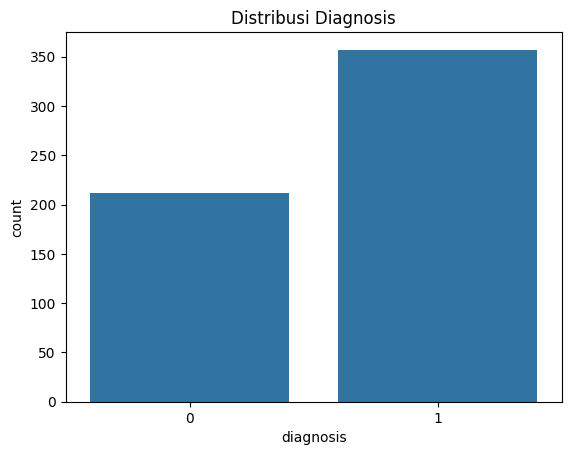

In [18]:
df.info()
sns.countplot(x='diagnosis', data=df)
plt.title("Distribusi Diagnosis")
plt.show()

4. preprocessing untuk merubah label jadi numerik

In [30]:
le = LabelEncoder()

df['diagnosis'] = le.fit_transform(df['diagnosis'])

df.head()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0
1,20.57,17.77,132.90,1326.0,0.08474,0
2,19.69,21.25,130.00,1203.0,0.10960,0
3,11.42,20.38,77.58,386.1,0.14250,0
4,20.29,14.34,135.10,1297.0,0.10030,0


5. pisahkan featur dan target

In [31]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

6. split data training dan testing

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

7. training model gausian naiv bayes

In [33]:
model = GaussianNB()

model.fit(X_train, y_train)

GaussianNB()

8. prediksi

In [34]:
y_pred = model.predict(X_test)

9. evaluasi mmodel

In [35]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9385964912280702


precisson, recall, dan f1 score

In [36]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.84      0.91        43
           1       0.91      1.00      0.95        71

    accuracy                           0.94       114
   macro avg       0.96      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



confusin matrix

In [37]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[36  7]
 [ 0 71]]


10. visualisasi confusin matrix

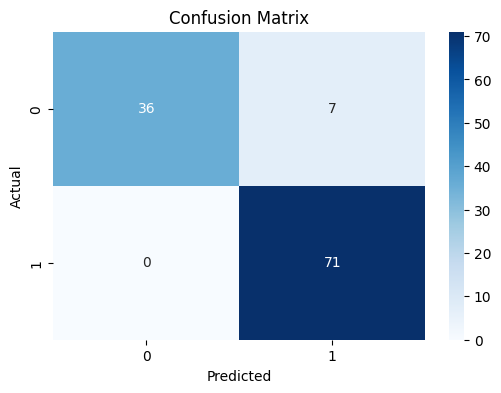

In [38]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()